# 06. Cuarta pregunta: ¿se puede predecir la marca de una atleta?

El objetivo aquí es doble: predecir el total que levantará una atleta y, sobre todo,
explicar qué lo determina.

## Cómo está diseñado el experimento

Hay tres decisiones de diseño que condicionan que los resultados sean creíbles.

La primera es usar validación temporal y no aleatoria. Se entrena con las
competiciones hasta 2022 y se valida con las de 2023 a 2026. Un reparto aleatorio
dejaría filas de la misma atleta a ambos lados del corte, y el modelo acertaría por
reconocerla y no por haber aprendido nada. La validación temporal reproduce el uso
real: predecir el futuro con datos del pasado.

La segunda es el control estricto de fuga de datos, que es el riesgo más serio en
este problema. El total es la suma de los tres levantamientos, así que incluir
`kg_sentadilla` daría un modelo perfecto e inútil. Se excluyen por diseño los tres
levantamientos y todas sus derivadas, los índices calculados sobre el total, las
variables que usan el total del propio evento y todo lo medido durante la
competición que se quiere predecir. El módulo lo comprueba con una asersión en
código, no de memoria.

La tercera es comparar contra una línea base, porque sin referencia un R² no
significa nada. Se comparan cuatro modelos de menor a mayor sofisticación, y los dos
últimos sobre las mismas filas, para que la mejora sea atribuible al modelo y no al
conjunto de prueba.

In [1]:
import sys
from pathlib import Path

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ / "src"))

import json
import pandas as pd
from IPython.display import Image, display

import config as cfg
import estilo
import modelos

estilo.aplicar()
pd.set_option("display.width", 140)
print("Modulo de modelado cargado.")

Modulo de modelado cargado.


## Las variables que entran y las que no

Merece la pena verlo de forma explícita, porque es la parte del trabajo que un
evaluador revisará con más atención.

In [2]:
print("VARIABLES DE PERFIL (se conocen antes de competir)")
print("  Numericas :", ", ".join(modelos.PERFIL_NUM))
print("  Categoricas:", ", ".join(modelos.PERFIL_CAT))
print()
print("VARIABLES DE HISTORIAL (marcas previas de la atleta)")
print("  ", ", ".join(modelos.HISTORIAL_NUM))
print()
print(f"EXCLUIDAS POR FUGA DE DATOS ({len(modelos.FUGA)} variables)")
for v in sorted(modelos.FUGA):
    print("  -", v)

VARIABLES DE PERFIL (se conocen antes de competir)
  Numericas : peso_corporal_kg, edad, anio, n_competicion, pib_per_capita_ppa, idh, indice_desigualdad_gen, tasa_actividad_femenina, esperanza_vida_femenina
  Categoricas: equipamiento, tipo_equipamiento, ambito_federacion, control_antidoping, region, iso3

VARIABLES DE HISTORIAL (marcas previas de la atleta)
   total_anterior, mejor_total_previo, dias_desde_anterior, total_competiciones_atleta, anios_trayectoria

EXCLUIDAS POR FUGA DE DATOS (39 variables)
  - brecha_fuerza_rel_pct
  - brecha_total_pct
  - categoria_peso_oficial
  - ciudad_competicion
  - division
  - es_podio
  - es_primera
  - es_record_personal
  - fecha
  - federacion
  - federacion_matriz
  - fuerza_rel_p50_m
  - fuerza_relativa
  - id_atleta
  - intentos_registrados
  - intentos_validos
  - kg_banca
  - kg_peso_muerto
  - kg_sentadilla
  - mejora_kg
  - mejora_pct
  - nombre_atleta
  - nombre_competicion
  - pct_banca
  - pct_peso_muerto
  - pct_sentadilla
  - pe

## Entrenamiento

Se ejecuta el experimento completo. Puede tardar un par de minutos.

In [3]:
entrena, prueba = modelos.preparar()


PREPARACION DE LOS DATOS


  Cargadas 825,296 filas y 22 columnas de dataset_final_powerlifting_femenino.csv
  Auditoria de fuga: OK (20 predictoras, 39 variables excluidas por diseño)

  Reparto TEMPORAL (no aleatorio):
    Entrenamiento  hasta 2022:  519,818 filas (63.0%)
    Prueba        2023-2026:  305,478 filas (37.0%)
    Total total_kg: media entrenamiento 301.4 kg, media prueba 308.1 kg


In [4]:
ajustados = modelos.entrenar(entrena, prueba)


ENTRENAMIENTO Y COMPARACION DE MODELOS

  Evaluacion sobre TODO el conjunto de prueba (305,478 filas)
  ----------------------------------------------------------------------
  1. Base (media)            MAE  64.67 kg | RMSE  82.28 kg | R2 -0.007 | error 22.96% |   0.0s


  2. Lineal (Ridge)          MAE  52.16 kg | RMSE  67.53 kg | R2  0.322 | error 17.96% |   3.6s


  3. Perfil (Gradient Boost) MAE  42.53 kg | RMSE  54.65 kg | R2  0.556 | error 14.92% |   7.0s
     -> arboles construidos: 400 (parada temprana activada)

  Comparacion JUSTA solo en filas con historial disponible
  ----------------------------------------------------------------------
  Entrenamiento 365,317 filas | prueba 232,409 filas (76.1% del total: el resto son debuts)


  3b. Perfil (mismas filas)  MAE  42.79 kg | RMSE  55.01 kg | R2  0.553 | error 14.39% |   0.0s


  4. Perfil + historial      MAE  15.61 kg | RMSE  24.55 kg | R2  0.911 | error  5.27% |   4.7s

  APORTACION DEL HISTORIAL: el error baja de 42.79 kg a 15.61 kg (63.5% menos)


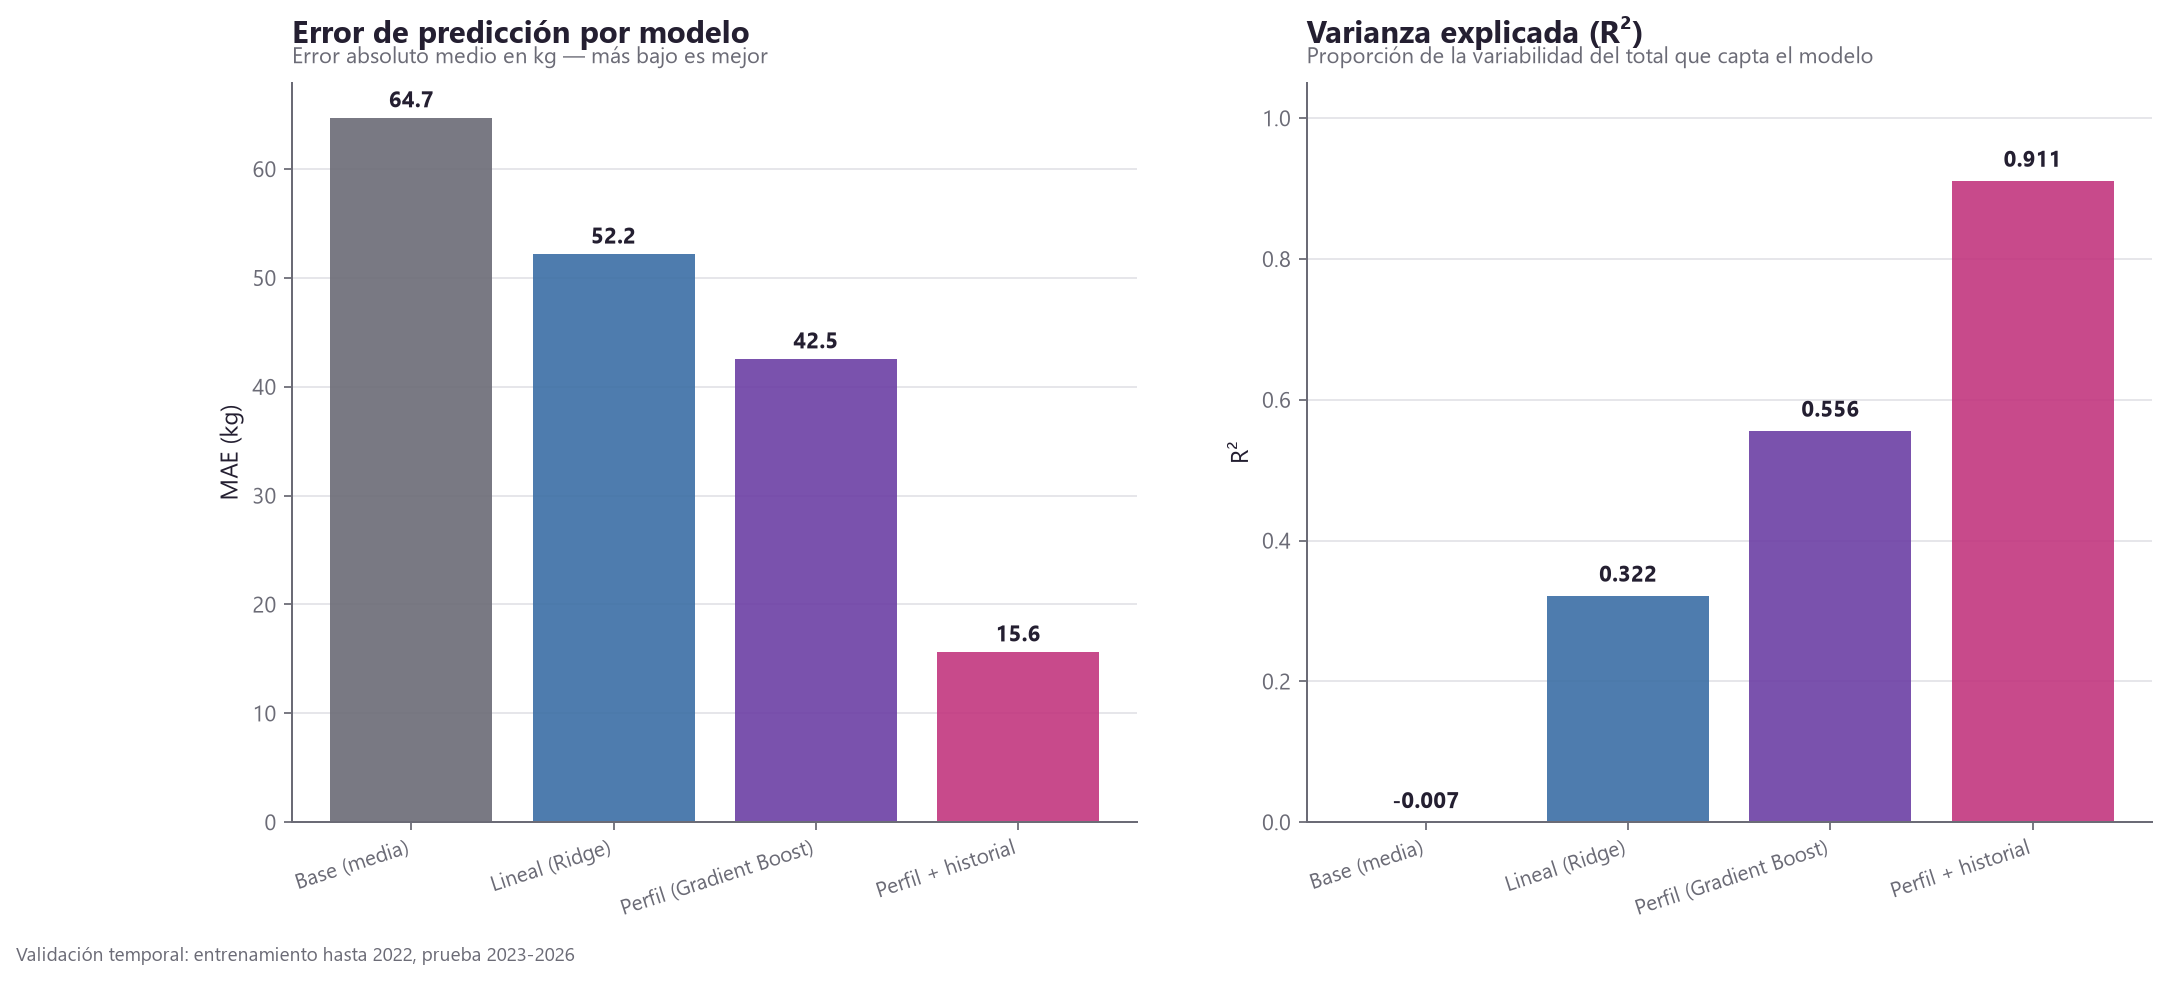

In [5]:
display(Image(filename=str(cfg.FIGURES / "m1_comparacion_modelos.png")))

## Lectura de los resultados

| Modelo | MAE | R² | Error relativo |
|---|---|---|---|
| Base (predecir la media) | 64,7 kg | −0,01 | 23,0% |
| Regresión lineal (Ridge) | 52,2 kg | 0,32 | 18,0% |
| Gradient boosting, solo perfil | 42,5 kg | 0,56 | 14,9% |
| Gradient boosting, perfil e historial | 15,6 kg | 0,91 | 5,3% |

De la tabla se extraen tres conclusiones.

El modelo base confirma que el problema no es trivial. Un R² de −0,01 significa que
predecir la media no sirve de nada, luego hay estructura real que aprender.

El gradient boosting supera con claridad al modelo lineal, pasando de 52 a 42 kg de
error, lo que indica la presencia de relaciones no lineales e interacciones que un
modelo lineal no captura. Es coherente con lo visto en la segunda pregunta, donde la
relación entre peso y fuerza resultó alométrica y no lineal.

Y conocer la trayectoria reduce el error un 63,5%. Esta es la comparación clave, y
es honesta porque ambos modelos se evalúan sobre las mismas 232.409 filas. Con
historial, el error baja al 5,3%, lo que para un total de 300 kg equivale a acertar
con un margen de unos 16 kg.

La conclusión práctica es que el mejor predictor de lo que levantará una atleta es
lo que levantó la última vez. Suena obvio, pero cuantificarlo tiene valor: indica
que el rendimiento en powerlifting es muy estable e inercial, y que las mejoras son
graduales y predecibles.

## Qué determina realmente el rendimiento

La pregunta más interesante no es cuánto acierta el modelo, sino qué ha aprendido.
Se usa importancia por permutación, que mide cuánto empeora el modelo al desordenar
cada variable. Es preferible a la importancia interna del árbol, que se sesga hacia
las variables de alta cardinalidad como el país, con sus 114 categorías.

In [6]:
importancia = modelos.explicar(ajustados)


EXPLICABILIDAD: QUE DETERMINA EL RENDIMIENTO
  Importancia por permutacion sobre 25,000 filas de prueba (5 repeticiones)...



  Variable                                Impacto (kg)  % del total
  Total en la competición anterior              46.021        66.8%
  Mejor total previo                            10.522        15.3%
  Peso corporal                                  2.753         4.0%
  Edad                                           2.331         3.4%
  Equipamiento                                   2.010         2.9%
  Días desde la anterior                         1.948         2.8%
  Nº de competición                              1.622         2.4%
  Competiciones totales de la atleta             0.732         1.1%
  Años de trayectoria                            0.477         0.7%
  Control antidopaje declarado                   0.166         0.2%
  Ámbito federativo                              0.122         0.2%
  País                                           0.113         0.2%
  Actividad laboral femenina                     0.012         0.0%
  IDH del país                                 

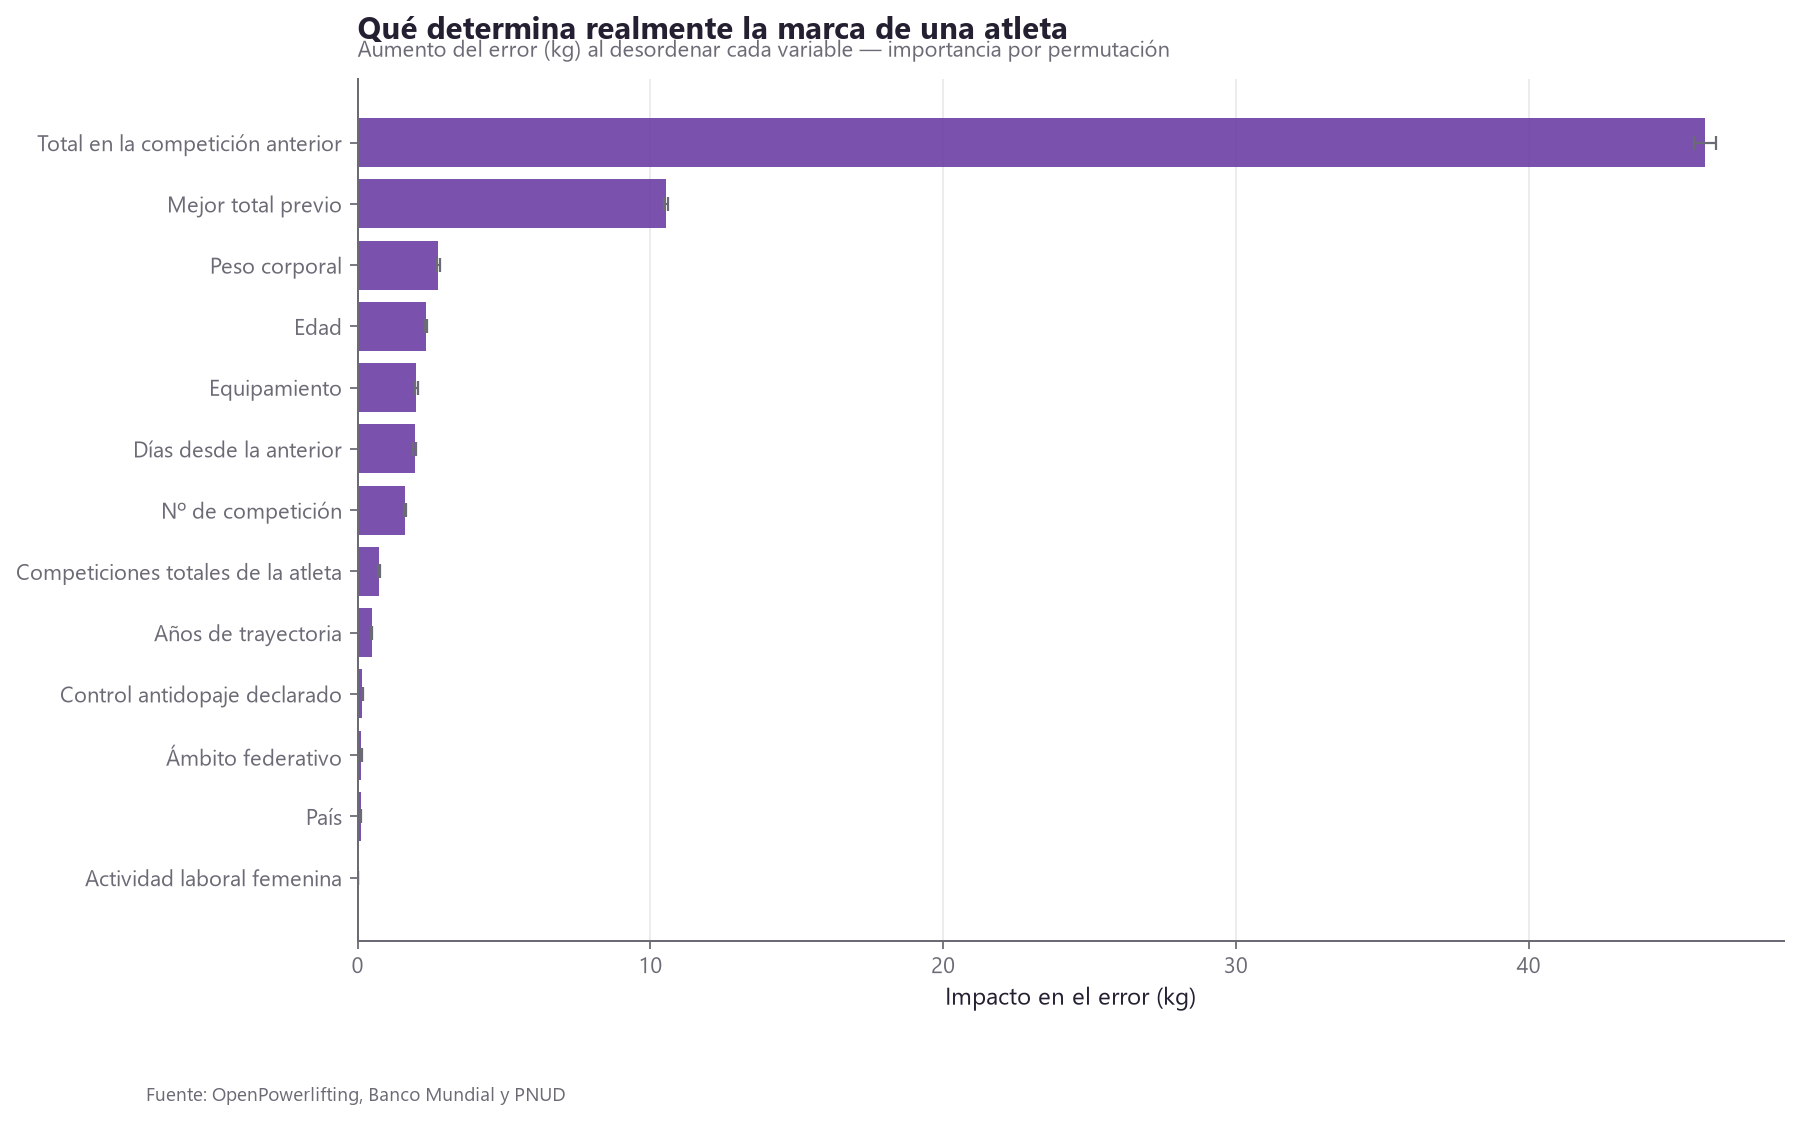

In [7]:
display(Image(filename=str(cfg.FIGURES / "m2_importancia_variables.png")))

### El hallazgo que unifica el proyecto

| Variable | % de la importancia |
|---|---|
| Total en la competición anterior | 66,8% |
| Mejor total previo | 15,3% |
| Peso corporal | 4,0% |
| Edad | 3,4% |
| Equipamiento | 2,9% |
| País | 0,2% |
| Actividad laboral femenina | 0,0% |
| IDH del país | 0,0% |

Caben dos lecturas.

La primera es que el rendimiento resulta fundamentalmente inercial: el historial
personal explica más del 80% de la capacidad predictiva, mientras que la biología
(peso y edad) aporta un 7% y el material un 3%.

La segunda es que el contexto socioeconómico del país es irrelevante para el
rendimiento individual. IDH, actividad laboral femenina y PIB quedan prácticamente
en cero.

Y aquí este cuaderno cierra el argumento de la tercera pregunta. Combinando ambos
resultados: el contexto económico del país influye en quién llega a competir, como
mostraba la correlación de 0,354 entre PIB per cápita y cuota femenina, pero no en
cuánto levanta quien ya compite, donde su importancia es del 0%.

El contexto actúa, por tanto, como filtro de entrada al deporte y no como
determinante del techo de rendimiento. Es una conclusión que ninguna de las dos
fuentes podría dar por separado: hace falta el cruce, lo que justifica el diseño del
proyecto.

## Diagnóstico: dónde falla el modelo

Un modelo no se evalúa solo por su métrica media. Hay que saber dónde se equivoca.

In [8]:
modelos.diagnosticar(ajustados)


DIAGNOSTICO: DONDE ACIERTA Y DONDE FALLA EL MODELO
  Residuo medio      : +0.850 kg  (cercano a 0 = sin sesgo sistematico)
  Desviacion tipica  : 24.53 kg
  Residuo mediano    : +1.360 kg
  Dentro de +-10 kg  : 48.8% de los casos
  Dentro de +-20 kg  : 75.4% de los casos

  ERROR POR TRAMO DE MARCA:
               n    mae  sesgo
tramo                         
<200 kg  14039.0  21.89  18.22
200-300  86331.0  13.91   4.70
300-400  95613.0  14.22  -3.74
400-500  31225.0  19.09 -12.02
>500 kg   5201.0  31.52 -24.29


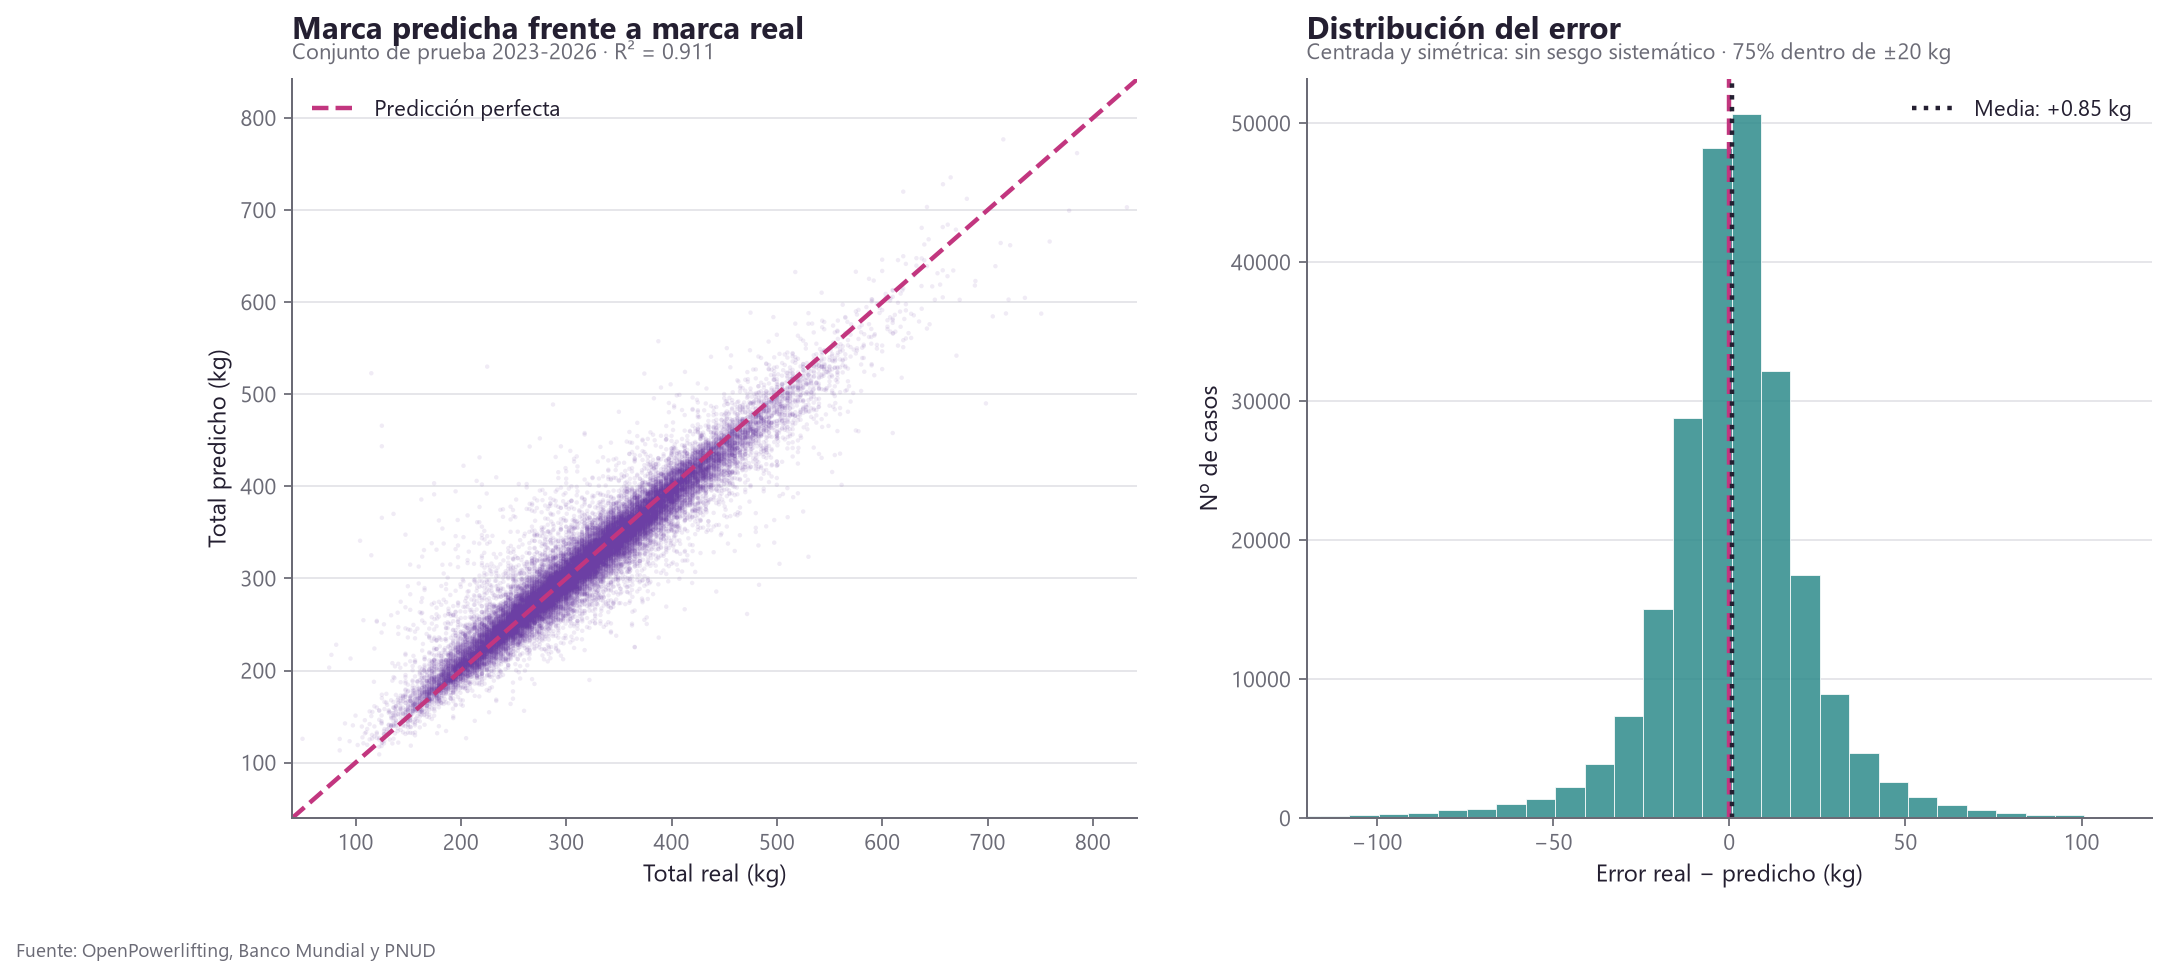

In [9]:
display(Image(filename=str(cfg.FIGURES / "m3_diagnostico_modelo.png")))

### Lectura crítica del diagnóstico

El residuo medio es de 0,85 kg sobre marcas de unos 300 kg, es decir, sin sesgo
sistemático apreciable. La distribución del error es simétrica y centrada, y el 75%
de las predicciones caen dentro de un margen de 20 kg.

Ahora bien, el error no es uniforme. Analizando por tramos aparece un patrón claro
de regresión a la media:

| Tramo | MAE | Sesgo |
|---|---|---|
| Menos de 200 kg | 21,9 kg | +18,2 (predice de más) |
| 200-300 kg | 13,9 kg | +4,7 |
| 300-400 kg | 14,2 kg | −3,7 |
| 400-500 kg | 19,1 kg | −12,0 |
| Más de 500 kg | 31,5 kg | −24,3 (predice de menos) |

El modelo comprime los extremos: sobreestima a las atletas más débiles y subestima a
las de élite. Es un comportamiento esperable en modelos que minimizan el error
cuadrático, porque los extremos están poco representados y la penalización por
equivocarse en el centro pesa más.

La implicación práctica es que el modelo resulta fiable en el rango de 200 a 400 kg,
donde está la gran mayoría de las atletas, pero debe usarse con cautela para
predecir marcas de élite, que es justamente donde una federación tendría más
interés. Reconocerlo vale más que ocultarlo.

## Limitaciones del modelado

Para ser honestos sobre el alcance de estos resultados, conviene señalar cuatro
limitaciones.

El modelo solo predice a quien ya tiene historial. El 24% de los registros son
debuts, y ahí el error se triplica hasta los 42,8 kg. No hay forma de saber qué
levantará alguien que nunca ha competido.

No hay datos de entrenamiento. Volumen, intensidad, años entrenando o lesiones no
constan en la fuente, y probablemente explicarían buena parte del 9% de varianza no
capturada.

El análisis habla de correlación y no de causalidad. Que el peso corporal sea
importante no significa que ganar peso mejore la marca de forma proporcional.

Y el sesgo geográfico se hereda: entrenado con datos donde Estados Unidos supone el
68%, es previsible que funcione peor en contextos poco representados.

## Síntesis de la cuarta pregunta

Sí se puede predecir la marca, con un error del 5,3% cuando se dispone de historial.
Lo que la determina es la trayectoria previa en un 82%, la biología en un 7% y el
material en un 3%. El país apenas influye, con un 0,2%. Y el modelo falla en los
extremos, donde comprime las predicciones hacia la media.